# Prepare co_3d

In [1]:
import os
import sys
import random
import numpy as np
import torch
import subprocess
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [2]:
# from co3d.dataset.data_types import load_dataclass_jgzip
from co3d.co3d.dataset.data_types import (
    load_dataclass_jgzip,
    FrameAnnotation,
    SequenceAnnotation,
)


In [3]:
dir_path = Path("/data/lab_moezkan/co3d_data/apple")
seq_annot_file = dir_path / "sequence_annotations.jgz"

seq_annnot = load_dataclass_jgzip(seq_annot_file, list[SequenceAnnotation])
seq_annnot

[SequenceAnnotation(sequence_name='110_13051_23361', category='apple', video=None, point_cloud=PointCloudAnnotation(path='apple/110_13051_23361/pointcloud.ply', quality_score=0.35655669649493715, n_points=418529), viewpoint_quality_score=1.8187577812976963),
 SequenceAnnotation(sequence_name='189_20393_38136', category='apple', video=None, point_cloud=PointCloudAnnotation(path='apple/189_20393_38136/pointcloud.ply', quality_score=-0.07052410402961273, n_points=595272), viewpoint_quality_score=1.541249247465535),
 SequenceAnnotation(sequence_name='540_79043_153212', category='apple', video=None, point_cloud=None, viewpoint_quality_score=nan)]

In [10]:
seq_dict = {seq.sequence_name: seq for seq in seq_annnot}
seq_dict

{'110_13051_23361': SequenceAnnotation(sequence_name='110_13051_23361', category='apple', video=None, point_cloud=PointCloudAnnotation(path='apple/110_13051_23361/pointcloud.ply', quality_score=0.35655669649493715, n_points=418529), viewpoint_quality_score=1.8187577812976963),
 '189_20393_38136': SequenceAnnotation(sequence_name='189_20393_38136', category='apple', video=None, point_cloud=PointCloudAnnotation(path='apple/189_20393_38136/pointcloud.ply', quality_score=-0.07052410402961273, n_points=595272), viewpoint_quality_score=1.541249247465535),
 '540_79043_153212': SequenceAnnotation(sequence_name='540_79043_153212', category='apple', video=None, point_cloud=None, viewpoint_quality_score=nan)}

: 

In [ ]:
ROOT_DIR = os.path.join(os.getcwd(), "co3d_data")

if not os.path.exists(ROOT_DIR):
    os.mkdir(ROOT_DIR)
print(ROOT_DIR)


!python /content/co3d/co3d/download_dataset.py --download_folder  $ROOT_DIR --single_sequence_subset


/content/co3d_data
  0% 0/1 [00:00<?, ?it/s]https://dl.fbaipublicfiles.com/co3dv2_231130/category_to_subset_name_list_singlesequence.json
/content/co3d_data/category_to_subset_name_list.json: 0.00iB [00:00, ?iB/s]category_to_subset_name_list.json: Downloaded 228600.0%.
/content/co3d_data/category_to_subset_name_list.json: 2.23kiB [00:00, 1.07MiB/s]
/content/co3d_data/category_to_subset_name_list.json: 2.23kiB [00:00, 883kiB/s]
100% 1/1 [00:00<00:00,  6.61it/s]
  0% 0/96 [00:00<?, ?it/s]Downloading dataset file apple_000.zip (https://dl.fbaipublicfiles.com/co3dv2_231130/apple_000_singlesequence.zip) to /content/co3d_data/_in_progress/apple_000.zip.
https://dl.fbaipublicfiles.com/co3dv2_231130/apple_001_singlesequence.zip
https://dl.fbaipublicfiles.com/co3dv2_231130/apple_000_singlesequence.zip
/content/co3d_data/_in_progress/apple_001.zip:   0% 0.00/191M [00:00<?, ?iB/s]apple_001.zip: Downloaded 0.0%.
/content/co3d_data/_in_progress/apple_001.zip:   0% 1.00k/191M [00:00<01:34, 2.11MiB/s

: 

# Dataset

In [4]:
from omegaconf import DictConfig, OmegaConf
import train as utils
from importlib import reload

from src.dataset.co3d import ProcessedCo3D

In [5]:
from omegaconf import OmegaConf
from src.data.co3d_dataset import CO3DDataset

# Load config
config = OmegaConf.load("config/plucker_vae_co3d.yaml")

# Extract dataset params from config
data_params = config.data.params.dataset_config.params
root_dir = config.co3d_dir
bb_file = config.bb_file

# Create dataset
dataset = CO3DDataset(
    root_dir=root_dir,
    bb_file=bb_file,
    image_size=data_params.image_size,
    include_plucker=data_params.include_plucker,
    n_patches=16,
    crop_images=data_params.crop_images,
    apply_augmentation=data_params.apply_augmentation,
)

print(f"Dataset loaded with {len(dataset)} samples")


[CO3DDataset] Loaded 4798 samples from /data/lab_moezkan/co3d_bboxes/toybus_test.jgz
[CO3DDataset] include_plucker=True, crop_images=True, augmentation=False
Dataset loaded with 4798 samples


4484


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.47483122..0.9742205].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4831467..1.7484311].


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

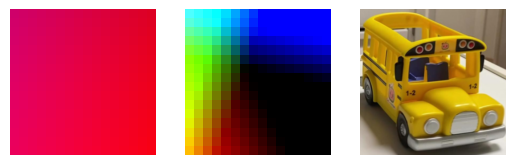

In [6]:
rnd_idx = random.randint(0, len(dataset) - 1)
rnd_idx = 4484
print(rnd_idx)

plt.subplot(1,3,1)
plt.imshow(dataset[rnd_idx]["plucker_coords"][:, :3].reshape(16, 16, 3).cpu())
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(dataset[rnd_idx]["plucker_coords"][:, 3:].reshape(16, 16, 3).cpu())
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(dataset[rnd_idx]["image"].permute(1,2,0).cpu()/ 2 + .5) 
plt.axis("off")


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6148007..0.86176884].


3441


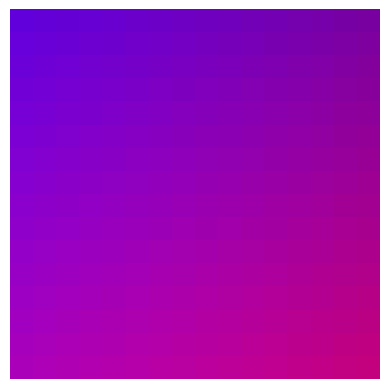

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.885794..3.0466251].


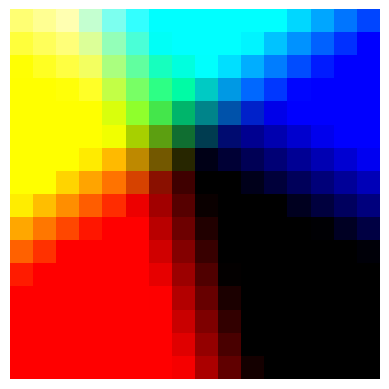

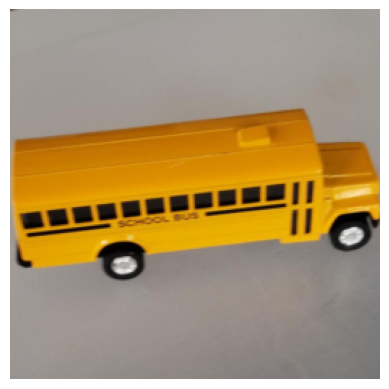

In [41]:
rnd_idx = random.randint(0, len(dataset) - 1)
rnd_idx = 3441

print(rnd_idx)

plt.imshow(dataset[rnd_idx]["plucker_coords"][:, :3].reshape(16, 16, 3).cpu())
plt.axis("off")
plt.show()

plt.imshow(dataset[rnd_idx]["plucker_coords"][:, 3:].reshape(16, 16, 3).cpu())
plt.axis("off")
plt.show()

plt.imshow(dataset[rnd_idx]["image"].permute(1,2,0).cpu()/ 2 + .5) 
plt.axis("off")
plt.show()


In [42]:
import torch.nn.functional as F

In [43]:
test_tensor = dataset[rnd_idx]["plucker_coords"][:, :3].reshape(16, 16, 3).cpu()

In [44]:
F.interpolate(test_tensor.permute(2,0,1), scale_factor=4, mode='linear').shape

torch.Size([3, 16, 64])

Mode: nearest, Resized shape: torch.Size([3, 64, 64])


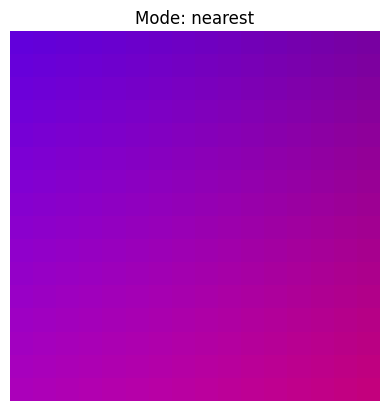

Mode: linear skipped (not applicable to 2D NCHW images).
Mode: bilinear, Resized shape: torch.Size([3, 64, 64])


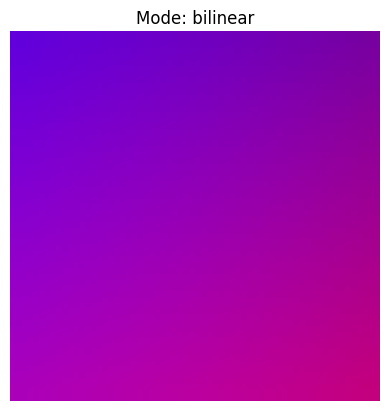

Mode: bicubic, Resized shape: torch.Size([3, 64, 64])


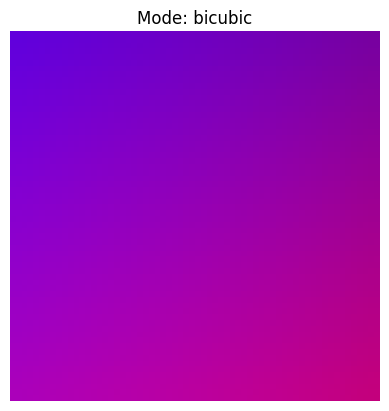

Mode: trilinear skipped (not applicable to 2D NCHW images).
Mode: area, Resized shape: torch.Size([3, 64, 64])


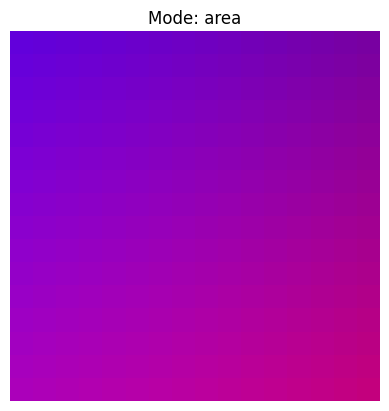

In [45]:

x4 = test_tensor.permute(2, 0, 1).unsqueeze(0)  # HWC -> NCHW (4D)

modes = ['nearest', 'linear', 'bilinear', 'bicubic', 'trilinear', 'area']

for mode in modes:
    # Only these are valid for 2D images (4D NCHW)
    if mode in ['linear', 'trilinear']:
        print(f"Mode: {mode} skipped (not applicable to 2D NCHW images).")
        continue

    kwargs = {}
    if mode in ['bilinear', 'bicubic']:
        kwargs['align_corners'] = False

    resized = F.interpolate(x4, size=(64, 64), mode=mode, **kwargs).squeeze(0)  # CHW
    print(f"Mode: {mode}, Resized shape: {resized.shape}")

    plt.imshow(resized.permute(1, 2, 0).detach().cpu().clamp(0, 1))
    plt.title(f"Mode: {mode}")
    plt.axis("off")
    plt.show()